In [1]:
import os
import cv2
import glob
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, 
                                     Conv2DTranspose, concatenate, 
                                     BatchNormalization, Activation, add)
from tensorflow.keras.callbacks import ModelCheckpoint
import tensorflow.keras.backend as K
from sklearn.model_selection import KFold

# Tắt warning
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')

print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

2026-04-06 05:31:21.877220: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775453482.101265      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775453482.168465      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775453482.701837      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775453482.701886      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775453482.701890      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
Num GPUs Available: 1


In [2]:
IMG_HEIGHT = 192
IMG_WIDTH = 256
N_CHANNELS = 3
BATCH_SIZE = 10        
EPOCHS = 150           
N_SPLITS = 5           
RANDOM_STATE = 3       
LEARNING_RATE = 1e-3   
ALPHA = 1.67

base_input_path = "/kaggle/input/datasets/quanhh42/multiresunet-datasets/CVC-ClinicDB/CVC-ClinicDB"

In [3]:
print("\nDang tim anh Original va Ground Truth...")

all_img_dirs = glob.glob(os.path.join(base_input_path, '**', '*Original*'), recursive=True)
all_msk_dirs = glob.glob(os.path.join(base_input_path, '**', '*Ground Truth*'), recursive=True)

all_img_dirs = [d for d in all_img_dirs if os.path.isdir(d)]
all_msk_dirs = [d for d in all_msk_dirs if os.path.isdir(d)]

image_dict = {}
for img_dir in all_img_dirs:
    for img_path in sorted(glob.glob(os.path.join(img_dir, '*.*'))):
        ext = os.path.splitext(img_path)[1].lower()
        if ext in ['.tif', '.tiff', '.png', '.jpg', '.bmp']:
            file_stem = os.path.splitext(os.path.basename(img_path))[0]
            if file_stem not in image_dict:
                image_dict[file_stem] = img_path

mask_dict = {}
for msk_dir in all_msk_dirs:
    for msk_path in sorted(glob.glob(os.path.join(msk_dir, '*.*'))):
        ext = os.path.splitext(msk_path)[1].lower()
        if ext in ['.tif', '.tiff', '.png', '.jpg', '.bmp']:
            file_stem = os.path.splitext(os.path.basename(msk_path))[0]
            if file_stem not in mask_dict:
                mask_dict[file_stem] = msk_path

common_stems = sorted(list(set(image_dict.keys()).intersection(set(mask_dict.keys()))))
print(f"Tim thay {len(common_stems)} cap anh (chuan la 612)")


Dang tim anh Original va Ground Truth...
Tim thay 612 cap anh (chuan la 612)


In [4]:
X = []
Y = []

for stem in tqdm(common_stems, desc="Loading images"):
    img = cv2.imread(image_dict[stem], cv2.IMREAD_COLOR)
    msk = cv2.imread(mask_dict[stem], cv2.IMREAD_GRAYSCALE)
    
    if img is not None and msk is not None:
        resized_img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_CUBIC)
        resized_msk = cv2.resize(msk, (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_NEAREST)
        
        X.append(resized_img)
        Y.append(resized_msk)

X = np.array(X)
Y = np.array(Y)
Y = Y.reshape((Y.shape[0], IMG_HEIGHT, IMG_WIDTH, 1))
X = X / 255.0
Y = Y / 255.0
Y = np.round(Y, 0)

print(f"\nDU LIEU DA SAN SANG! X shape: {X.shape}, Y shape: {Y.shape}")

Loading images: 100%|██████████| 612/612 [00:12<00:00, 50.97it/s]



DU LIEU DA SAN SANG! X shape: (612, 192, 256, 3), Y shape: (612, 192, 256, 1)


In [5]:
def jacard(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f + y_pred_f - y_true_f * y_pred_f)
    return intersection / (union + K.epsilon())

def dice_coef(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2.0 * intersection + K.epsilon()) / (K.sum(y_true_f) + K.sum(y_pred_f) + K.epsilon())

In [6]:
def conv_block(inputs, num_filters):
    x = Conv2D(num_filters, (3, 3), padding='same', activation='relu', kernel_initializer='he_normal')(inputs)
    x = Conv2D(num_filters, (3, 3), padding='same', activation='relu', kernel_initializer='he_normal')(x)
    return x

def build_unet_baseline(input_shape=(IMG_HEIGHT, IMG_WIDTH, N_CHANNELS)):
    inputs = Input(input_shape)
    s1 = conv_block(inputs, 32)
    p1 = MaxPooling2D((2, 2))(s1)
    s2 = conv_block(p1, 64)
    p2 = MaxPooling2D((2, 2))(s2)
    s3 = conv_block(p2, 128)
    p3 = MaxPooling2D((2, 2))(s3)
    s4 = conv_block(p3, 256)
    p4 = MaxPooling2D((2, 2))(s4)
    b5 = conv_block(p4, 512)

    u6 = Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(b5)
    c6 = concatenate([u6, s4], axis=3)
    d6 = conv_block(c6, 256)
    u7 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(d6)
    c7 = concatenate([u7, s3], axis=3)
    d7 = conv_block(c7, 128)
    u8 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(d7)
    c8 = concatenate([u8, s2], axis=3)
    d8 = conv_block(c8, 64)
    u9 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(d8)
    c9 = concatenate([u9, s1], axis=3)
    d9 = conv_block(c9, 32)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(d9)
    return Model(inputs, outputs, name='UNet_Baseline')

In [7]:
# 2. MultiResUNet
def conv2d_bn(x, filters, num_row, num_col, padding='same', strides=(1, 1), activation='relu', name=None):
    x = Conv2D(filters, (num_row, num_col), strides=strides, padding=padding, use_bias=False)(x)
    x = BatchNormalization(axis=3, scale=False)(x)
    if activation is not None:
        x = Activation(activation, name=name)(x)
    return x

def MultiResBlock(U, inp, alpha=1.67):
    W = alpha * U
    shortcut = inp
    shortcut = conv2d_bn(shortcut, int(W*0.167) + int(W*0.333) + int(W*0.5), 
                         1, 1, activation=None, padding='same')
    
    conv3x3 = conv2d_bn(inp, int(W*0.167), 3, 3, activation='relu', padding='same')
    conv5x5 = conv2d_bn(conv3x3, int(W*0.333), 3, 3, activation='relu', padding='same')
    conv7x7 = conv2d_bn(conv5x5, int(W*0.5), 3, 3, activation='relu', padding='same')
    
    out = concatenate([conv3x3, conv5x5, conv7x7], axis=3)
    out = BatchNormalization(axis=3)(out)
    out = add([shortcut, out])
    out = Activation('relu')(out)
    out = BatchNormalization(axis=3)(out)
    return out

def ResPath(filters, length, inp):
    shortcut = inp
    shortcut = conv2d_bn(shortcut, filters, 1, 1, activation=None, padding='same')
    out = conv2d_bn(inp, filters, 3, 3, activation='relu', padding='same')
    out = add([shortcut, out])
    out = Activation('relu')(out)
    out = BatchNormalization(axis=3)(out)
    
    for i in range(length - 1):
        shortcut = out
        shortcut = conv2d_bn(shortcut, filters, 1, 1, activation=None, padding='same')
        out = conv2d_bn(out, filters, 3, 3, activation='relu', padding='same')
        out = add([shortcut, out])
        out = Activation('relu')(out)
        out = BatchNormalization(axis=3)(out)
    return out

def build_multiresunet(height=IMG_HEIGHT, width=IMG_WIDTH, n_channels=N_CHANNELS):
    inputs = Input((height, width, n_channels))
    mresblock1 = MultiResBlock(32, inputs)
    pool1 = MaxPooling2D(pool_size=(2, 2))(mresblock1)
    mresblock1 = ResPath(32, 4, mresblock1)
    
    mresblock2 = MultiResBlock(32*2, pool1)
    pool2 = MaxPooling2D(pool_size=(2, 2))(mresblock2)
    mresblock2 = ResPath(32*2, 3, mresblock2)
    
    mresblock3 = MultiResBlock(32*4, pool2)
    pool3 = MaxPooling2D(pool_size=(2, 2))(mresblock3)
    mresblock3 = ResPath(32*4, 2, mresblock3)
    
    mresblock4 = MultiResBlock(32*8, pool3)
    pool4 = MaxPooling2D(pool_size=(2, 2))(mresblock4)
    mresblock4 = ResPath(32*8, 1, mresblock4)
    
    mresblock5 = MultiResBlock(32*16, pool4)
    
    up6 = concatenate([Conv2DTranspose(32*8, (2, 2), strides=(2, 2), padding='same')(mresblock5), 
                       mresblock4], axis=3)
    mresblock6 = MultiResBlock(32*8, up6)
    
    up7 = concatenate([Conv2DTranspose(32*4, (2, 2), strides=(2, 2), padding='same')(mresblock6), 
                       mresblock3], axis=3)
    mresblock7 = MultiResBlock(32*4, up7)
    
    up8 = concatenate([Conv2DTranspose(32*2, (2, 2), strides=(2, 2), padding='same')(mresblock7), 
                       mresblock2], axis=3)
    mresblock8 = MultiResBlock(32*2, up8)
    
    up9 = concatenate([Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(mresblock8), 
                       mresblock1], axis=3)
    mresblock9 = MultiResBlock(32, up9)
    
    conv10 = Conv2D(1, (1, 1), activation='sigmoid')(mresblock9)
    return Model(inputs=[inputs], outputs=[conv10], name='MultiResUNet')

In [8]:
def train_and_evaluate(build_fn, model_name, X, Y, kf):
    os.makedirs(f'models_{model_name}', exist_ok=True)
    
    fold_jaccard = []
    fold_dice = []
    all_histories = []
    best_fold_idx = 0
    best_fold_jaccard = 0
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
        print(f"\n--- {model_name.upper()} - Dang chay Fold {fold}/{N_SPLITS} ---")
        K.clear_session()
        
        X_train_fold, X_val_fold = X[train_idx], X[val_idx]
        Y_train_fold, Y_val_fold = Y[train_idx], Y[val_idx]
        
        model = build_fn()
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
            loss='binary_crossentropy',
            metrics=[jacard, dice_coef]
        )
        
        checkpoint_path = f'models_{model_name}/{model_name}_cvc_fold{fold}_best.weights.h5'
        checkpoint = ModelCheckpoint(
            checkpoint_path, monitor='val_jacard', mode='max',
            save_best_only=True, save_weights_only=True, verbose=0
        )
        
        history = model.fit(
            X_train_fold, Y_train_fold,
            validation_data=(X_val_fold, Y_val_fold),
            batch_size=BATCH_SIZE, epochs=EPOCHS,
            callbacks=[checkpoint], verbose=0 # Tắt log verbose để gọn output
        )
        
        all_histories.append(history)
        max_jac_fold = max(history.history['val_jacard'])
        max_dic_fold = max(history.history['val_dice_coef'])
        
        fold_jaccard.append(max_jac_fold)
        fold_dice.append(max_dic_fold)
        print(f"Ket qua Fold {fold} ({model_name}): Jaccard = {max_jac_fold*100:.2f}% | Dice = {max_dic_fold*100:.2f}%")
        
        if max_jac_fold > best_fold_jaccard:
            best_fold_jaccard = max_jac_fold
            best_fold_idx = fold
            
    return fold_jaccard, fold_dice, all_histories, best_fold_idx

In [9]:
def draw_mask_contour(img_rgb, mask, color, thickness=2):
    mask_uint8 = (mask * 255).astype(np.uint8)
    contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    img_with_contour = img_rgb.copy()
    cv2.drawContours(img_with_contour, contours, -1, color, thickness)
    return img_with_contour

def visualize_paper_comparison(X_test, Y_test, unet_model, multi_model, num_samples=5):
    print("\nDang tao anh Demo Comparison (U-Net vs MultiResUNet)...")
    yp_unet = np.round(unet_model.predict(X_test, verbose=0), 0)
    yp_multi = np.round(multi_model.predict(X_test, verbose=0), 0)
    
    COLOR_GT = (0, 255, 0)      # Xanh luc
    COLOR_MULTI = (0, 0, 255)   # Xanh duong
    COLOR_UNET = (255, 0, 0)    # Do

    num_samples = min(num_samples, len(X_test))
    for i in range(num_samples):
        fig, axes = plt.subplots(1, 5, figsize=(25, 5))
        img_original = (X_test[i] * 255).astype(np.uint8)
        img_rgb = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
        
        axes[0].imshow(img_rgb)
        axes[0].set_title('Input Image', fontsize=14)
        axes[0].axis('off')
        
        axes[1].imshow(Y_test[i].squeeze(), cmap='gray')
        axes[1].set_title('Ground Truth', fontsize=14)
        axes[1].axis('off')
        
        axes[2].imshow(yp_multi[i].squeeze(), cmap='gray')
        axes[2].set_title('Output from MultiResUNet', fontsize=14)
        axes[2].axis('off')
        
        axes[3].imshow(yp_unet[i].squeeze(), cmap='gray')
        axes[3].set_title('Output from U-Net', fontsize=14)
        axes[3].axis('off')
        
        comp_img = img_rgb.copy()
        comp_img = draw_mask_contour(comp_img, Y_test[i].squeeze(), COLOR_GT)
        comp_img = draw_mask_contour(comp_img, yp_multi[i].squeeze(), COLOR_MULTI)
        comp_img = draw_mask_contour(comp_img, yp_unet[i].squeeze(), COLOR_UNET)
        
        axes[4].imshow(comp_img)
        axes[4].set_title('Comparison', fontsize=14)
        axes[4].axis('off')
        
        gt_patch = mpatches.Patch(color=[c/255 for c in COLOR_GT], label='Ground Truth')
        multi_patch = mpatches.Patch(color=[c/255 for c in COLOR_MULTI], label='MultiResUNet')
        unet_patch = mpatches.Patch(color=[c/255 for c in COLOR_UNET], label='U-Net')
        axes[4].legend(handles=[gt_patch, multi_patch, unet_patch], loc='upper left', fontsize=10)
        
        plt.tight_layout()
        plt.savefig(f'comparison_demo_{i}.png', format='png', dpi=150, bbox_inches='tight')
        plt.show()

In [10]:

kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# 1. Train U-Net
unet_jaccard, unet_dice, unet_histories, unet_best_fold = train_and_evaluate(
    build_unet_baseline, 'unet', X, Y, kf)

# 2. Train MultiResUNet
multi_jaccard, multi_dice, multi_histories, multi_best_fold = train_and_evaluate(
    build_multiresunet, 'multiresunet', X, Y, kf)


--- UNET - Dang chay Fold 1/5 ---


I0000 00:00:1775453530.560992      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1775453538.380684     122 service.cc:152] XLA service 0x7a9164005b70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775453538.380742     122 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775453539.600142     122 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-06 05:32:22.899611: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 05:32:23.134646: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accurac

Ket qua Fold 1 (unet): Jaccard = 69.91% | Dice = 81.89%

--- UNET - Dang chay Fold 2/5 ---
Ket qua Fold 2 (unet): Jaccard = 67.51% | Dice = 79.93%

--- UNET - Dang chay Fold 3/5 ---
Ket qua Fold 3 (unet): Jaccard = 68.44% | Dice = 80.85%

--- UNET - Dang chay Fold 4/5 ---
Ket qua Fold 4 (unet): Jaccard = 67.32% | Dice = 79.28%

--- UNET - Dang chay Fold 5/5 ---
Ket qua Fold 5 (unet): Jaccard = 69.14% | Dice = 81.34%

--- MULTIRESUNET - Dang chay Fold 1/5 ---
Ket qua Fold 1 (multiresunet): Jaccard = 80.22% | Dice = 88.86%

--- MULTIRESUNET - Dang chay Fold 2/5 ---
Ket qua Fold 2 (multiresunet): Jaccard = 79.49% | Dice = 88.28%

--- MULTIRESUNET - Dang chay Fold 3/5 ---
Ket qua Fold 3 (multiresunet): Jaccard = 81.56% | Dice = 89.68%

--- MULTIRESUNET - Dang chay Fold 4/5 ---
Ket qua Fold 4 (multiresunet): Jaccard = 77.20% | Dice = 86.52%

--- MULTIRESUNET - Dang chay Fold 5/5 ---
Ket qua Fold 5 (multiresunet): Jaccard = 79.00% | Dice = 88.04%


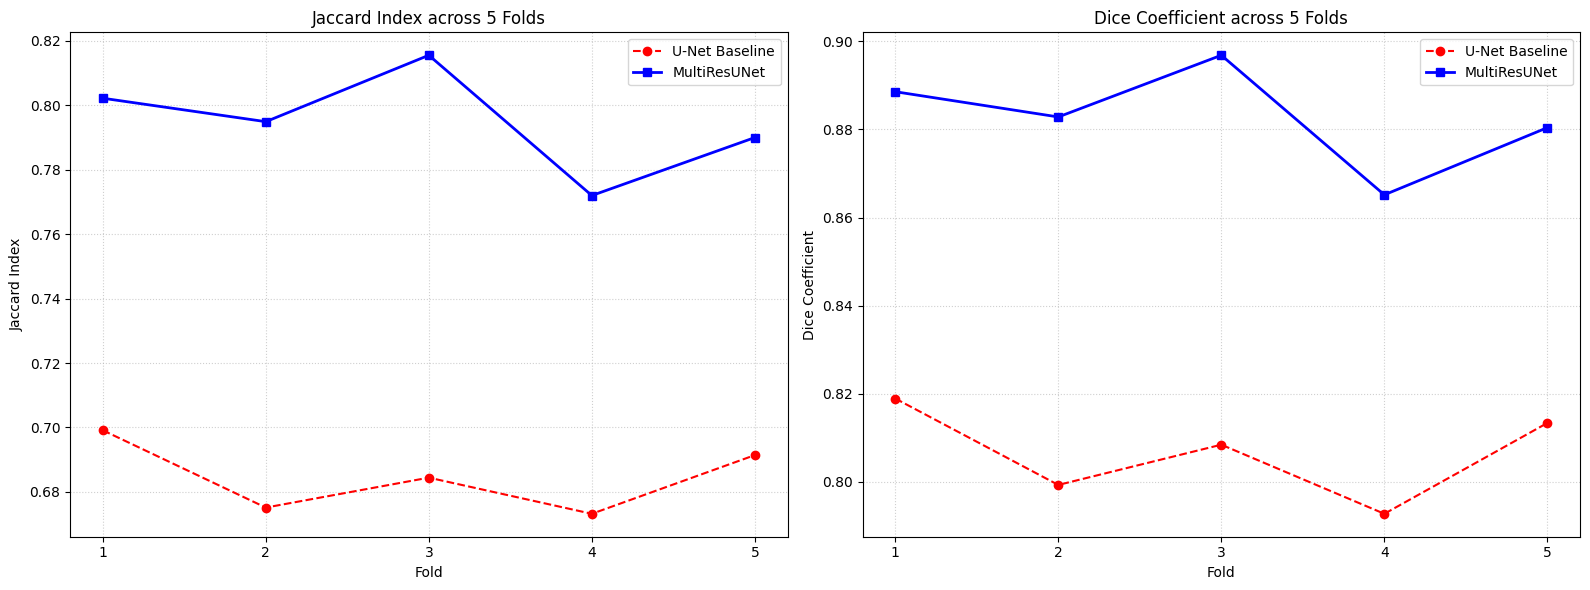


Dang tao anh Demo Comparison (U-Net vs MultiResUNet)...


2026-04-06 08:42:49.312752: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 08:42:49.553334: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


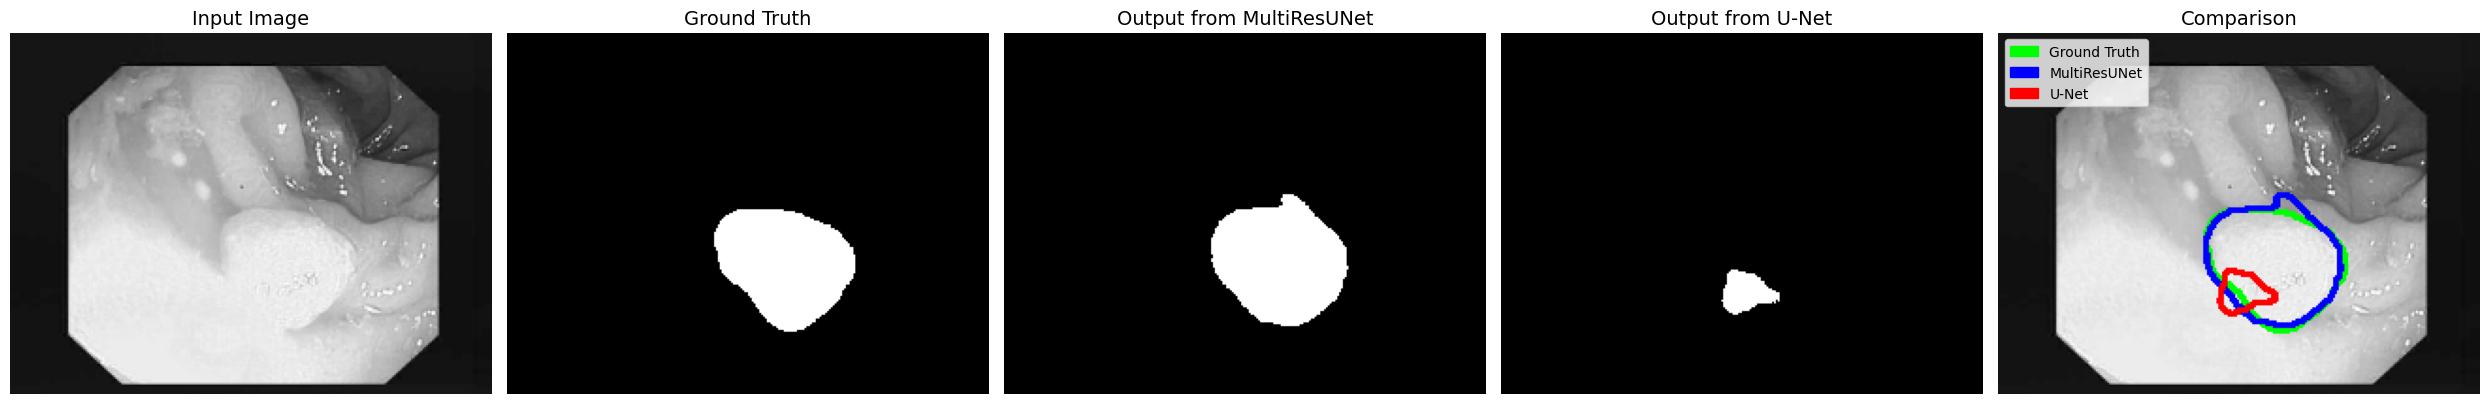

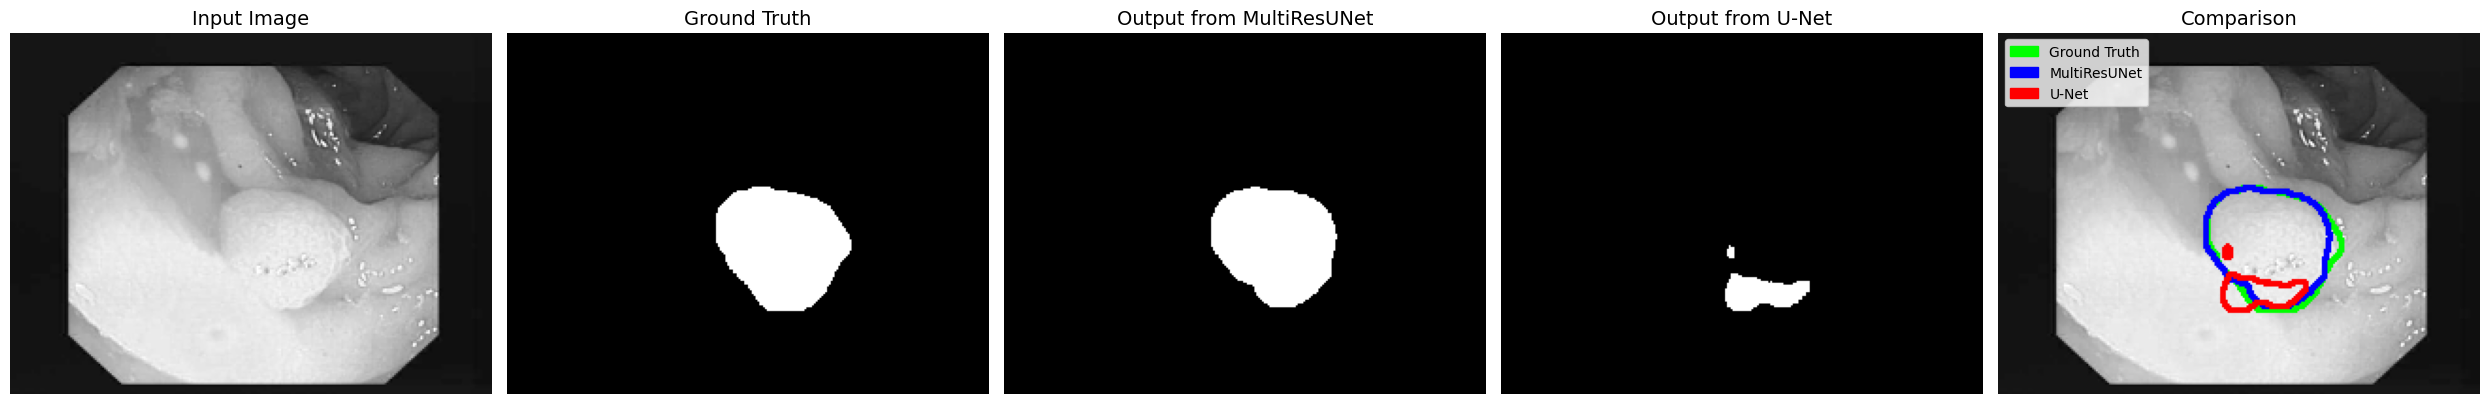

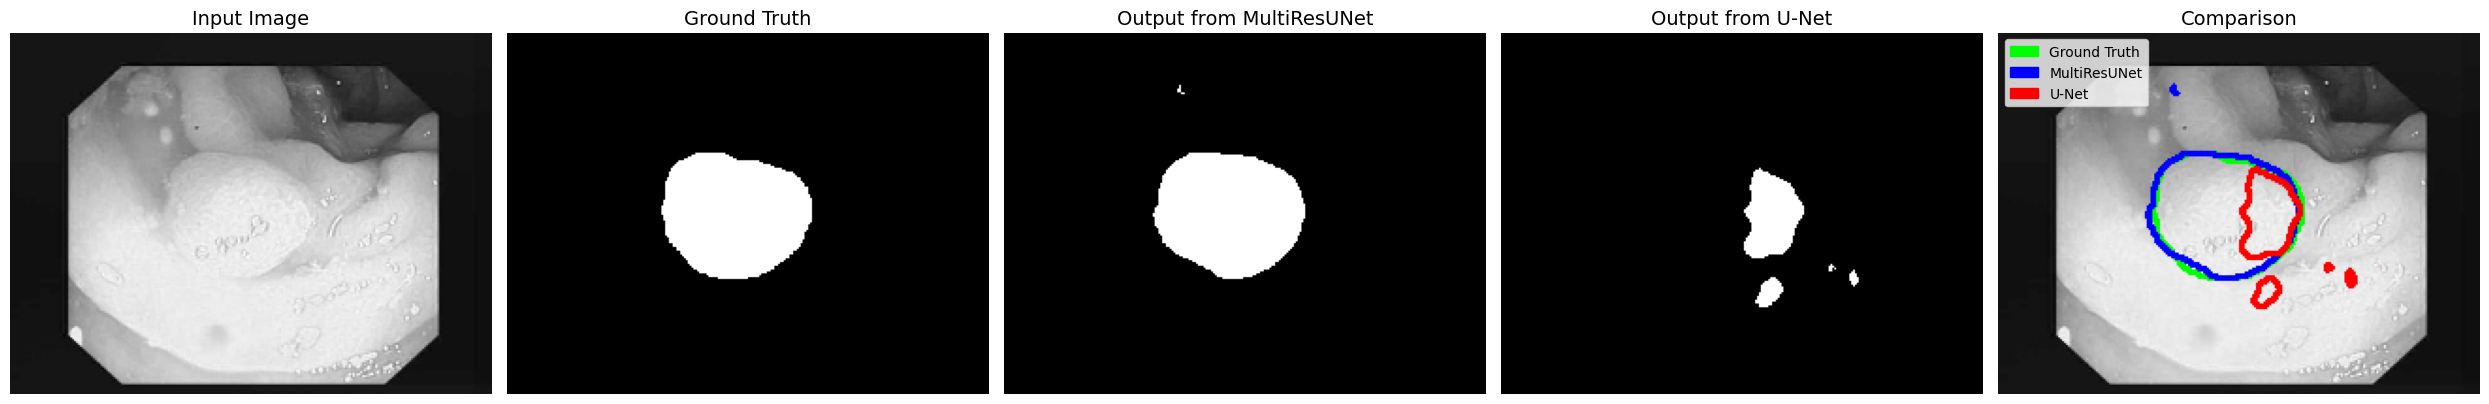

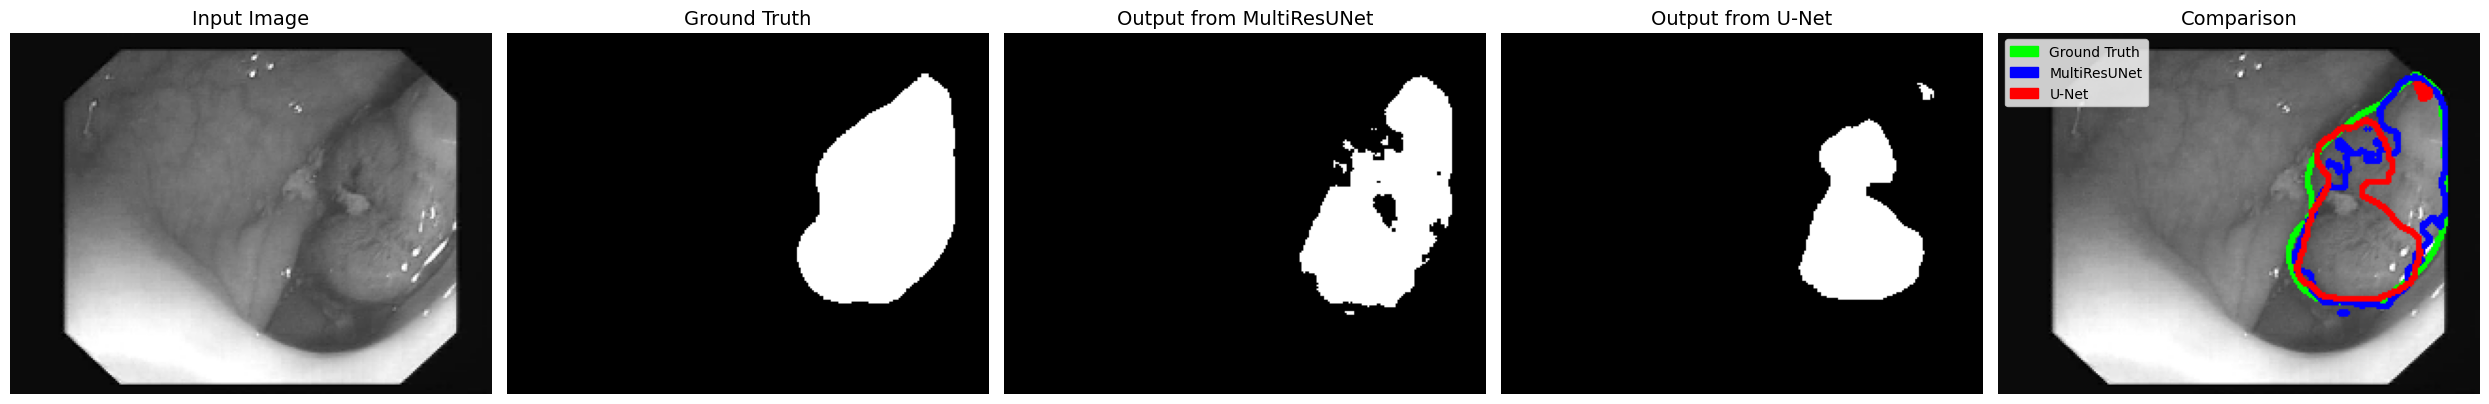

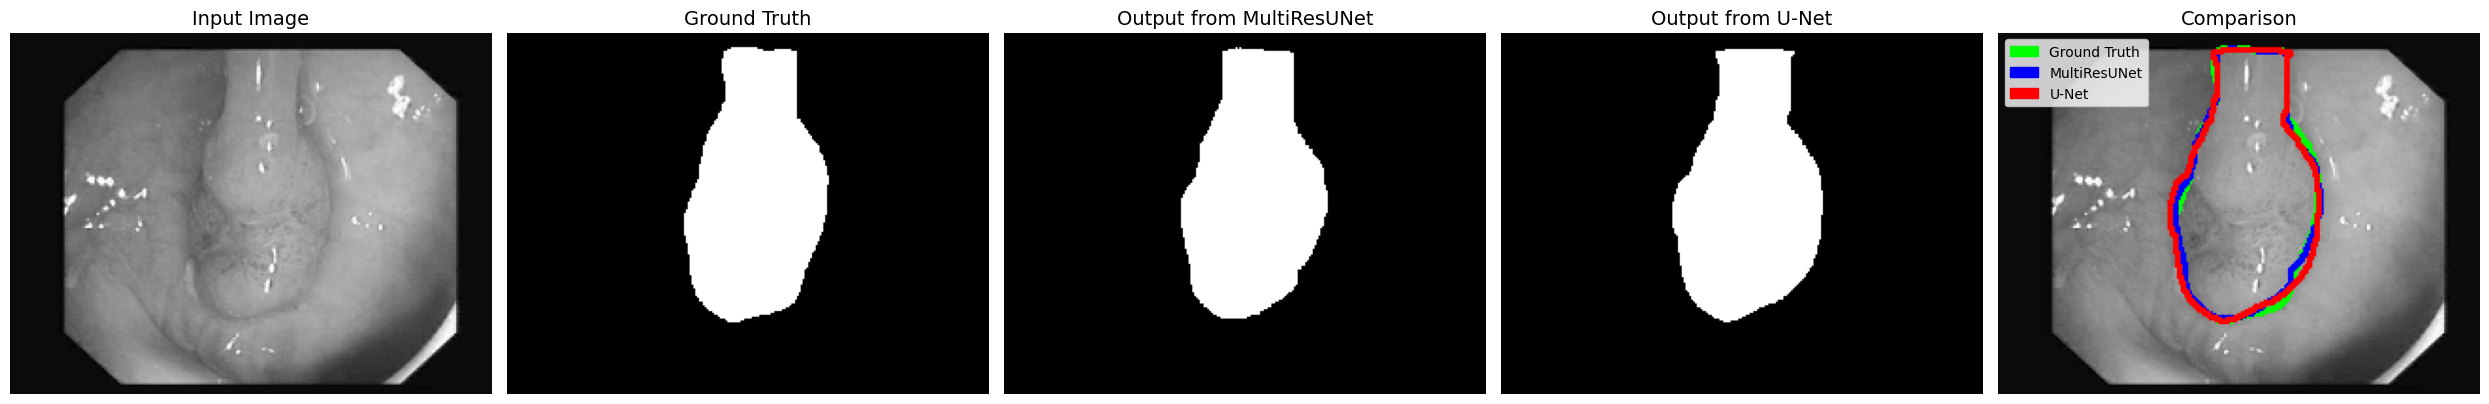


✅ HOAN TAT TOAN BO QUA TRINH!


In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import cv2

# 1. Hàm vẽ biểu đồ đường Line (So sánh 5 Fold)
def plot_kfold_comparison(unet_jaccard, multi_jaccard, unet_dice, multi_dice):
    folds = np.arange(1, 6)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Bieu do Jaccard
    ax1.plot(folds, unet_jaccard, marker='o', label='U-Net Baseline', linestyle='--', color='red')
    ax1.plot(folds, multi_jaccard, marker='s', label='MultiResUNet', linewidth=2, color='blue')
    ax1.set_title('Jaccard Index across 5 Folds')
    ax1.set_xlabel('Fold')
    ax1.set_ylabel('Jaccard Index')
    ax1.set_xticks(folds)
    ax1.legend()
    ax1.grid(True, linestyle=':', alpha=0.6)
    
    # Bieu do Dice
    ax2.plot(folds, unet_dice, marker='o', label='U-Net Baseline', linestyle='--', color='red')
    ax2.plot(folds, multi_dice, marker='s', label='MultiResUNet', linewidth=2, color='blue')
    ax2.set_title('Dice Coefficient across 5 Folds')
    ax2.set_xlabel('Fold')
    ax2.set_ylabel('Dice Coefficient')
    ax2.set_xticks(folds)
    ax2.legend()
    ax2.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.savefig('KFold_Comparison_Graph.png', dpi=150)
    plt.show()

# 2. Hàm hỗ trợ vẽ viền đè lên ảnh
def draw_mask_contour(img_rgb, mask, color, thickness=2):
    mask_uint8 = (mask * 255).astype(np.uint8)
    contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    img_with_contour = img_rgb.copy()
    cv2.drawContours(img_with_contour, contours, -1, color, thickness)
    return img_with_contour

# 3. Hàm xuất hình ảnh Demo 5 Cột
def visualize_paper_comparison(X_test, Y_test, unet_model, multi_model, num_samples=5):
    print("\nDang tao anh Demo Comparison (U-Net vs MultiResUNet)...")
    yp_unet = np.round(unet_model.predict(X_test, verbose=0), 0)
    yp_multi = np.round(multi_model.predict(X_test, verbose=0), 0)
    
    COLOR_GT = (0, 255, 0)      # Xanh luc (Thực tế)
    COLOR_MULTI = (0, 0, 255)   # Xanh duong (MultiRes)
    COLOR_UNET = (255, 0, 0)    # Do (U-Net)

    num_samples = min(num_samples, len(X_test))
    for i in range(num_samples):
        fig, axes = plt.subplots(1, 5, figsize=(25, 5))
        img_original = (X_test[i] * 255).astype(np.uint8)
        img_rgb = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
        
        axes[0].imshow(img_rgb)
        axes[0].set_title('Input Image', fontsize=14)
        axes[0].axis('off')
        
        axes[1].imshow(Y_test[i].squeeze(), cmap='gray')
        axes[1].set_title('Ground Truth', fontsize=14)
        axes[1].axis('off')
        
        axes[2].imshow(yp_multi[i].squeeze(), cmap='gray')
        axes[2].set_title('Output from MultiResUNet', fontsize=14)
        axes[2].axis('off')
        
        axes[3].imshow(yp_unet[i].squeeze(), cmap='gray')
        axes[3].set_title('Output from U-Net', fontsize=14)
        axes[3].axis('off')
        
        comp_img = img_rgb.copy()
        comp_img = draw_mask_contour(comp_img, Y_test[i].squeeze(), COLOR_GT)
        comp_img = draw_mask_contour(comp_img, yp_multi[i].squeeze(), COLOR_MULTI)
        comp_img = draw_mask_contour(comp_img, yp_unet[i].squeeze(), COLOR_UNET)
        
        axes[4].imshow(comp_img)
        axes[4].set_title('Comparison', fontsize=14)
        axes[4].axis('off')
        
        gt_patch = mpatches.Patch(color=[c/255 for c in COLOR_GT], label='Ground Truth')
        multi_patch = mpatches.Patch(color=[c/255 for c in COLOR_MULTI], label='MultiResUNet')
        unet_patch = mpatches.Patch(color=[c/255 for c in COLOR_UNET], label='U-Net')
        axes[4].legend(handles=[gt_patch, multi_patch, unet_patch], loc='upper left', fontsize=10)
        
        plt.tight_layout()
        plt.savefig(f'comparison_demo_{i}.png', format='png', dpi=150, bbox_inches='tight')
        plt.show()

# ============================================================================
# GỌI LẠI CÁC HÀM HIỂN THỊ (Vì data đã có sẵn trong RAM)
# ============================================================================
# Vẽ đồ thị so sánh
plot_kfold_comparison(unet_jaccard, multi_jaccard, unet_dice, multi_dice)

# Lấy dữ liệu Validation của Fold tốt nhất của mạng MultiResUNet để làm Demo
train_idx_best, val_idx_best = list(kf.split(X))[multi_best_fold - 1]
X_val_demo = X[val_idx_best]
Y_val_demo = Y[val_idx_best]

# Load Weights tốt nhất
K.clear_session()
best_unet = build_unet_baseline()
best_unet.load_weights(f'models_unet/unet_cvc_fold{multi_best_fold}_best.weights.h5')

best_multi = build_multiresunet()
best_multi.load_weights(f'models_multiresunet/multiresunet_cvc_fold{multi_best_fold}_best.weights.h5')

# Xuất Demo Comparison
visualize_paper_comparison(X_val_demo, Y_val_demo, best_unet, best_multi, num_samples=5)
print("\n✅ HOAN TAT TOAN BO QUA TRINH!")

Đang trích xuất dữ liệu và vẽ biểu đồ...


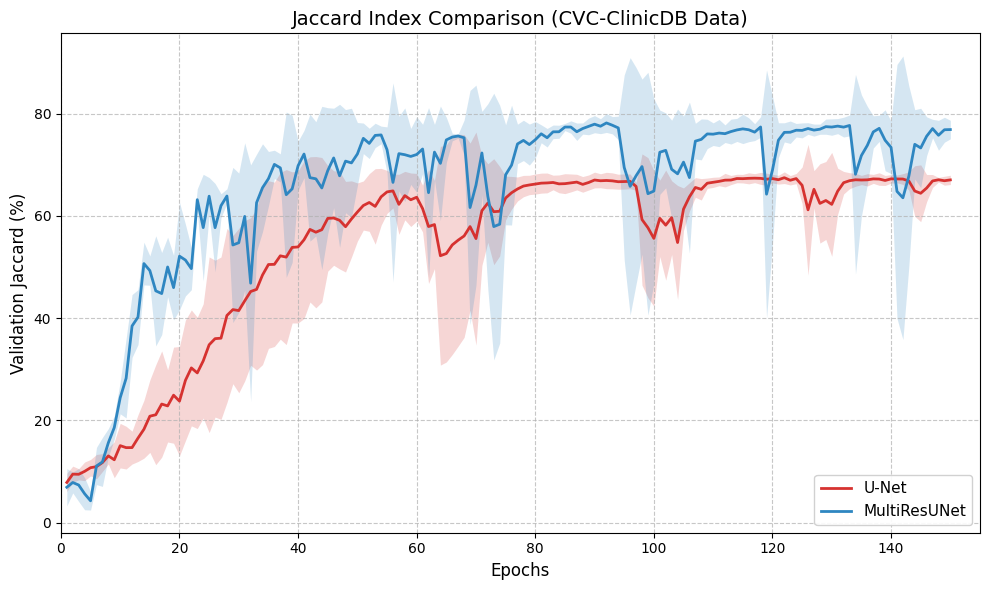

Đã lưu biểu đồ thành công: 'Paper_Style_Learning_Curve.png'


In [14]:
import numpy as np
import matplotlib.pyplot as plt

def plot_paper_learning_curve(unet_histories, multi_histories, metric='val_jacard', title_metric='Validation Jaccard (%)'):
    """
    Hàm móc dữ liệu từ lịch sử huấn luyện 5-Fold và vẽ biểu đồ so sánh có bóng mờ (Variance)
    Đã đảo thứ tự Legend: U-Net nằm trên, MultiResUNet nằm dưới
    """
    print("Đang trích xuất dữ liệu và vẽ biểu đồ...")
    
    # 1. Trích xuất dữ liệu của 5 Folds (Chuyển sang dạng phần trăm %)
    unet_data = np.array([h.history[metric] for h in unet_histories]) * 100
    multi_data = np.array([h.history[metric] for h in multi_histories]) * 100
    
    # Lấy mốc trục X là số Epochs (1 đến 150)
    epochs = np.arange(1, unet_data.shape[1] + 1)
    
    # 2. Tính Trung bình (Mean) và Độ lệch chuẩn (Std)
    unet_mean = np.mean(unet_data, axis=0)
    unet_std = np.std(unet_data, axis=0)
    
    multi_mean = np.mean(multi_data, axis=0)
    multi_std = np.std(multi_data, axis=0)
    
    # 3. Tiến hành vẽ biểu đồ
    plt.figure(figsize=(10, 6))
    
    # VẼ U-NET TRƯỚC ĐỂ LÊN TOP LEGNED (Đường màu Đỏ)
    plt.plot(epochs, unet_mean, label='U-Net', color='#D63230', linewidth=2)
    plt.fill_between(epochs, 
                     unet_mean - unet_std, 
                     unet_mean + unet_std, 
                     color='#D63230', alpha=0.2, linewidth=0)

    # VẼ MULTIRESUNET SAU ĐỂ NẰM DƯỚI LEGEND (Đường màu Xanh dương)
    plt.plot(epochs, multi_mean, label='MultiResUNet', color='#2E86C1', linewidth=2)
    plt.fill_between(epochs, 
                     multi_mean - multi_std, 
                     multi_mean + multi_std, 
                     color='#2E86C1', alpha=0.2, linewidth=0)
    
    
    # 4. Trang trí biểu đồ chuẩn bài báo (Paper-style)
    plt.title('Jaccard Index Comparison (CVC-ClinicDB Data)', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel(title_metric, fontsize=12)
    
    # Lưới kẻ (Grid) mờ
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Ghi chú (Legend) ở góc dưới bên phải
    plt.legend(loc='lower right', fontsize=11, framealpha=0.9)
    
    # Giới hạn trục Y và X cho đẹp mắt
    plt.xlim(0, len(epochs) + 5)
    
    plt.tight_layout()
    plt.savefig('Paper_Style_Learning_Curve.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Đã lưu biểu đồ thành công: 'Paper_Style_Learning_Curve.png'")

# ============================================================================
# GỌI HÀM VẼ BIỂU ĐỒ 
# ============================================================================
# Vẽ cho Jaccard Index
plot_paper_learning_curve(unet_histories, multi_histories, metric='val_jacard', title_metric='Validation Jaccard (%)')

# Nếu muốn vẽ thêm cho Dice thì bạn bỏ dấu '#' ở dòng dưới nha:
# plot_paper_learning_curve(unet_histories, multi_histories, metric='val_dice_coef', title_metric='Validation Dice (%)')

In [ ]:
# import os
# import cv2
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.patches as mpatches

In [ ]:
# def draw_mask_contour(img_rgb, mask, color, thickness=1):
#     """
#     Vẽ đường viền từ mask nhị phân lên ảnh màu RGB.
#     """
#     # Ép kiểu mask về uint8 [0, 255]
#     mask_uint8 = (mask * 255).astype(np.uint8)
    
#     # Tìm đường viền
#     contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
#     # Vẽ đường viền đè lên ảnh
#     img_with_contour = img_rgb.copy()
#     cv2.drawContours(img_with_contour, contours, -1, color, thickness)
#     return img_with_contour

In [ ]:
# def show_paper_demo(X_test, Y_test, unet_model, multi_model, num_samples=5):
#     """
#     Hiển thị demo 5 mẫu so sánh y hệt định dạng của bài báo.
#     """
#     print(" Đang chạy dự đoán cho cả 2 mô hình, vui lòng đợi...")
#     yp_unet = np.round(unet_model.predict(X_test, verbose=0), 0)
#     yp_multi = np.round(multi_model.predict(X_test, verbose=0), 0)
    
#     # Mã màu RGB chuẩn theo bài báo
#     COLOR_GT = (0, 255, 0)      # Xanh lục (Ground Truth)
#     COLOR_MULTI = (0, 0, 255)   # Xanh dương (MultiResUNet)
#     COLOR_UNET = (255, 0, 0)    # Đỏ (U-Net)

#     # Đảm bảo không lấy vượt quá số ảnh đang có
#     num_samples = min(num_samples, len(X_test))
    
#     for i in range(num_samples):
#         fig, axes = plt.subplots(1, 5, figsize=(25, 5))
        
#         # 1. Ảnh Input
#         img_original = (X_test[i] * 255).astype(np.uint8)
#         img_rgb = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
#         axes[0].imshow(img_rgb)
#         axes[0].set_title('Input Image', fontsize=14)
#         axes[0].axis('off')
        
#         # 2. Ground Truth Mask
#         axes[1].imshow(Y_test[i].squeeze(), cmap='gray')
#         axes[1].set_title('Ground Truth', fontsize=14)
#         axes[1].axis('off')
        
#         # 3. MultiResUNet Mask
#         axes[2].imshow(yp_multi[i].squeeze(), cmap='gray')
#         axes[2].set_title('Output from MultiResUNet', fontsize=14)
#         axes[2].axis('off')
        
#         # 4. U-Net Mask
#         axes[3].imshow(yp_unet[i].squeeze(), cmap='gray')
#         axes[3].set_title('Output from U-Net', fontsize=14)
#         axes[3].axis('off')
        
#         # 5. COMPARISON (Ảnh chồng viền)
#         comp_img = img_rgb.copy()
#         # Lần lượt vẽ đè 3 đường viền lên ảnh gốc
#         comp_img = draw_mask_contour(comp_img, Y_test[i].squeeze(), COLOR_GT)
#         comp_img = draw_mask_contour(comp_img, yp_multi[i].squeeze(), COLOR_MULTI)
#         comp_img = draw_mask_contour(comp_img, yp_unet[i].squeeze(), COLOR_UNET)
        
#         axes[4].imshow(comp_img)
#         axes[4].set_title('Comparison', fontsize=14)
#         axes[4].axis('off')
        
#         # Thêm chú giải (Legend) góc trên bên trái
#         gt_patch = mpatches.Patch(color=[c/255 for c in COLOR_GT], label='Ground Truth')
#         multi_patch = mpatches.Patch(color=[c/255 for c in COLOR_MULTI], label='MultiResUNet')
#         unet_patch = mpatches.Patch(color=[c/255 for c in COLOR_UNET], label='U-Net')
#         axes[4].legend(handles=[gt_patch, multi_patch, unet_patch], loc='upper left', fontsize=10)
        
#         plt.tight_layout()
#         plt.show()

In [ ]:
# import tensorflow.keras.backend as K

# print("\n" + "="*60)
# print("  TẠO 5 MẪU DEMO SO SÁNH (U-NET vs MULTIRESUNET)")
# print("="*60)

# K.clear_session()

# # 1. Khởi tạo và Load weights mạng U-Net
# print("1. Đang nạp mô hình U-Net Baseline...")
# demo_unet = build_unet_baseline(input_shape=(IMG_HEIGHT, IMG_WIDTH, N_CHANNELS))
# # Trỏ đúng vào thư mục và file weights của U-Net
# demo_unet.load_weights(f'models_unet/unet_cvc_fold{best_fold_idx}_best.weights.h5')

# # 2. Khởi tạo và Load weights mạng MultiResUNet
# print("2. Đang nạp mô hình MultiResUNet...")
# demo_multires = build_multiresunet(IMG_HEIGHT, IMG_WIDTH, N_CHANNELS)
# # Trỏ đúng vào thư mục và file weights của MultiResUNet
# demo_multires.load_weights(f'models_multiresunet/multiresunet_cvc_fold{best_fold_idx}_best.weights.h5')

# # 3. Hiển thị 5 ảnh ngẫu nhiên
# print("\n3. Đang vẽ Demo Comparison...")
# show_paper_demo(X_val_best, Y_val_best, demo_unet, demo_multires, num_samples=5)

In [ ]:
# def show_multires_demo(X_test, Y_test, model, num_samples=5):
#     """
#     Hiển thị demo 5 mẫu so sánh cho mạng MultiResUNet.
#     """
#     print(" Đang chạy dự đoán cho mô hình MultiResUNet, vui lòng đợi...")
#     yp_multi = np.round(model.predict(X_test, verbose=0), 0)
    
#     # Mã màu RGB
#     COLOR_GT = (0, 255, 0)      # Xanh lục (Ground Truth)
#     COLOR_MULTI = (0, 0, 255)   # Xanh dương (MultiResUNet)

#     # Đảm bảo không lấy vượt quá số ảnh đang có
#     num_samples = min(num_samples, len(X_test))
    
#     for i in range(num_samples):
#         fig, axes = plt.subplots(1, 4, figsize=(20, 5))
        
#         # 1. Ảnh Input
#         img_original = (X_test[i] * 255).astype(np.uint8)
#         img_rgb = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
#         axes[0].imshow(img_rgb)
#         axes[0].set_title('Input Image', fontsize=14)
#         axes[0].axis('off')
        
#         # 2. Ground Truth Mask
#         axes[1].imshow(Y_test[i].squeeze(), cmap='gray')
#         axes[1].set_title('Ground Truth', fontsize=14)
#         axes[1].axis('off')
        
#         # 3. MultiResUNet Mask
#         axes[2].imshow(yp_multi[i].squeeze(), cmap='gray')
#         axes[2].set_title('Output from MultiResUNet', fontsize=14)
#         axes[2].axis('off')
        
#         # 4. COMPARISON (Ảnh chồng viền)
#         comp_img = img_rgb.copy()
#         comp_img = draw_mask_contour(comp_img, Y_test[i].squeeze(), COLOR_GT)
#         comp_img = draw_mask_contour(comp_img, yp_multi[i].squeeze(), COLOR_MULTI)
        
#         axes[3].imshow(comp_img)
#         axes[3].set_title('Comparison', fontsize=14)
#         axes[3].axis('off')
        
#         # Thêm chú giải (Legend) góc trên bên trái
#         gt_patch = mpatches.Patch(color=[c/255 for c in COLOR_GT], label='Ground Truth')
#         multi_patch = mpatches.Patch(color=[c/255 for c in COLOR_MULTI], label='MultiResUNet')
#         axes[3].legend(handles=[gt_patch, multi_patch], loc='upper left', fontsize=10)
        
#         plt.tight_layout()
#         plt.show()

In [ ]:
# K.clear_session()

# # Khởi tạo và Load weights mạng MultiResUNet
# # Chú ý: Dùng lại biến best_fold_idx từ khối code chạy 5-Fold trước đó
# print("1. Đang nạp mô hình MultiResUNet...")
# demo_multires = build_multiresunet(IMG_HEIGHT, IMG_WIDTH, N_CHANNELS)
# demo_multires.load_weights(f'models_multiresunet/multiresunet_cvc_fold{best_fold_idx}_best.weights.h5')

# # Hiển thị 5 ảnh ngẫu nhiên từ tập Validation của Fold tốt nhất
# print("\n2. Đang vẽ Demo Comparison...")
# show_multires_demo(X_val_best, Y_val_best, demo_multires, num_samples=5)

In [ ]:
# # MultiResUNet
# evaluate_model_kfold(model_type='multiresunet', X_data=X, Y_data=Y, n_folds=5)